Here, we will perform several segmentations using different combinations of columns from our dataset. The goal is to implement the best possible segmentations in order to group the data in a relevant way and thus better understand our customers.
It should be noted that the results of the segmentation can generally be used to score customers.

In [0]:
import pandas as pd 
import numpy as np

Knowledge of our dataset (number of rows/columns, column types, descriptive statistics and so on)

In [0]:
data = pd.read_csv('Mall_Customers.csv', sep=';')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [0]:
data.shape

(200, 5)

In [0]:
data.rename(columns={'Annual Income (k$)':'Annual Income', 'Spending Score (1-100)':'Spending Score'}, inplace=True)

In [0]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income', 'Spending Score'], dtype='object')

In [0]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      200 non-null    int64 
 1   Gender          200 non-null    object
 2   Age             200 non-null    int64 
 3   Annual Income   200 non-null    int64 
 4   Spending Score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [0]:
data.describe()

,CustomerID,Age,Annual Income,Spending Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [0]:
data_prep = data.copy()

In [0]:
data_prep.drop('CustomerID', axis=1, inplace=True)

In [0]:
from sklearn.preprocessing import StandardScaler

# Variables used for our segmentation
segmentation_columns = ['Age', 'Spending Score']
X_segmentation = data_prep[segmentation_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_segmentation)

Here, to determine the optimal number of clusters based on our dataset and the selected segmentation columns, we will use the Elbow method. This method consists of implementing a K-means model on arbitrary values of K and calculating the sum of inertia (which is the intra-cluster distance) at each step. The goal is to establish the number of clusters for which we have the lowest inertia.

In [0]:
# Méthode Elbow 
from sklearn.cluster import KMeans

inertie = []
for i in range(1,10):
    kmeans = KMeans(i)
    kmeans.fit(X_scaled)
    inertie_iteration=kmeans.inertia_
    inertie.append(inertie_iteration)
inertie

[400.00000000000006,
 189.38749033992428,
 126.63343205080368,
 90.28285952205034,
 71.5906989173433,
 63.14955480295849,
 45.9228759149183,
 40.10339710305332,
 34.97656917737332]

Text(0, 0.5, 'Inertia')

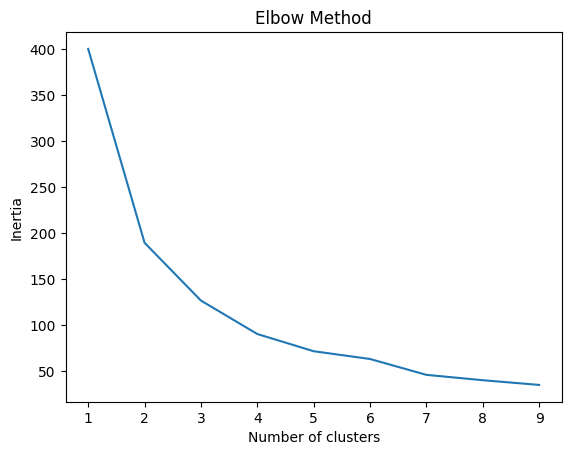

In [0]:
# We want to visualize the evolution of our inertia

import matplotlib.pyplot as plt 
import seaborn as sns  

nombre_clusters = range(1,10)

plt.plot(nombre_clusters, inertie)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

After viewing the evolution of our inertia, we determine that the optimal number of clusters here is 5. This is the number at which the curve begins to slow down more gradually, which means that this is the number of clusters that allows us to have enough clusters with significant similarities between them and dissimilarities with other groupings.

In [0]:
# Implementation of our K-means
# We therefore choose, using the Elbow method, to take 5 clusters.

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

In [0]:
data_clusters = data_prep.copy()
data_clusters['Clusters'] = kmeans.fit_predict(X_scaled) 
data_clusters.head()

,Gender,Age,Annual Income,Spending Score,Clusters
0,Male,19,15,39,2
1,Male,21,15,81,1
2,Female,20,16,6,4
3,Female,23,16,77,1
4,Female,31,17,40,2


Text(0, 0.5, 'Spending Score')

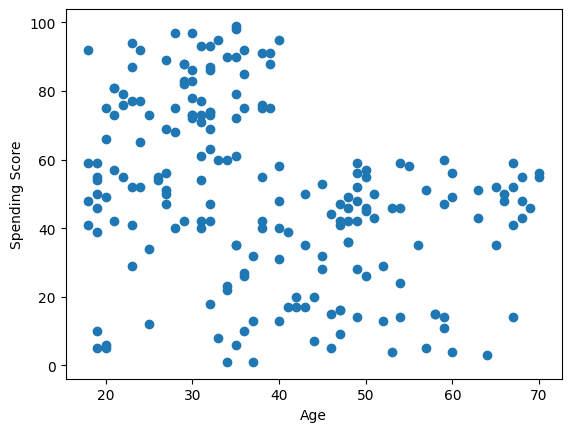

In [0]:
# Before Clustering 

plt.scatter(data_prep['Age'],data_prep['Spending Score'])
plt.xlabel('Age')
plt.ylabel('Spending Score')

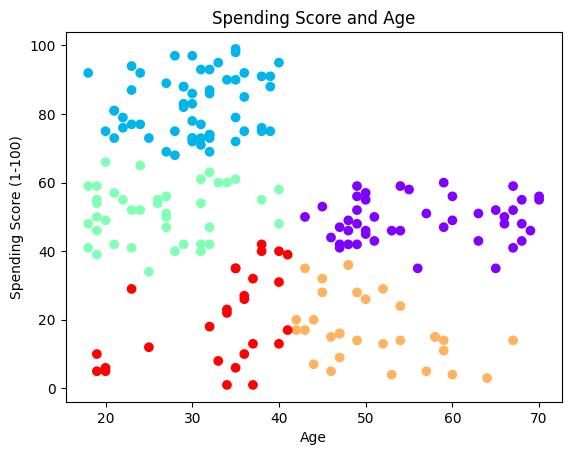

In [0]:
# After Clustering

plt.scatter(data_prep['Age'],data_prep['Spending Score'], c=data_clusters['Clusters'], cmap='rainbow')
plt.title('Spending Score and Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

We repeat the same process here with the “Expense Score” and “Annual Income” columns

In [0]:
# Variables used for our segmentation
segmentation_columns_2 = ['Spending Score', 'Annual Income']
X2_segmentation = data_prep[segmentation_columns_2]

X2_scaled = scaler.fit_transform(X2_segmentation)

In [0]:
# Méthode Elbow 

inertie2 = []
for i in range(1,10):
    kmeans = KMeans(i)
    kmeans.fit(X2_scaled)
    inertie_iteration=kmeans.inertia_
    inertie2.append(inertie_iteration)
inertie2

[400.0,
 273.66888662642015,
 157.70400815035947,
 109.22822707921347,
 99.0984470815257,
 57.2894494172146,
 50.06096236923081,
 39.53258729911727,
 32.948985000543786]

Text(0, 0.5, 'Inertia')

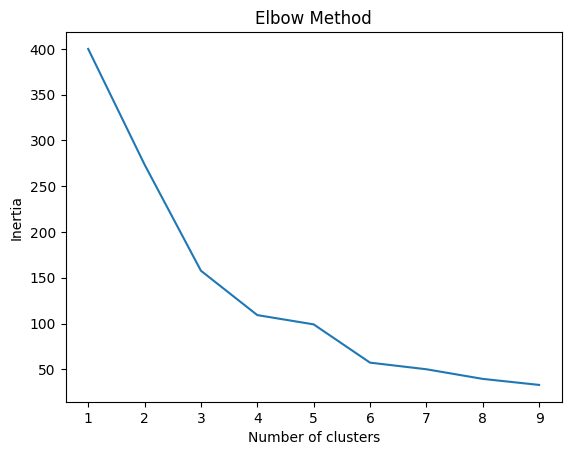

In [0]:
plt.plot(nombre_clusters, inertie2)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

In [0]:
# Implementation of our K-means
# As before, we select five clusters

kmeans2 = KMeans(n_clusters=5, random_state=42)
kmeans2.fit(X2_scaled)

KMeans(n_clusters=5, random_state=42)

In [0]:
data_clusters2 = data_prep.copy()
data_clusters2['Clusters'] = kmeans2.fit_predict(X2_scaled) 
data_clusters2.head()

,Gender,Age,Annual Income,Spending Score,Clusters
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


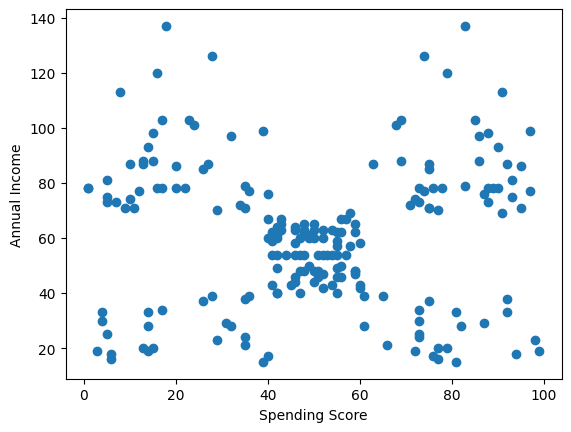

In [0]:
# Before Clustering

plt.scatter(data_prep['Spending Score'],data_prep['Annual Income'])
plt.xlabel('Spending Score')
plt.ylabel('Annual Income')
plt.show()

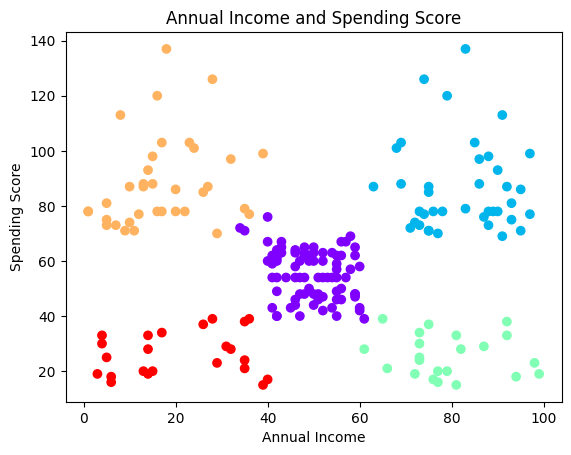

In [0]:
# After Clustering

plt.scatter(data_prep['Spending Score'],data_prep['Annual Income'], c=data_clusters2['Clusters'], cmap='rainbow')
plt.title('Annual Income and Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

On répète le même processus ici sur les colonnes 'Age' et 'Annual Income'

In [0]:
# Variables used for our segmentation
segmentation_columns_3 = ['Age', 'Annual Income']
X3_segmentation = data_prep[segmentation_columns_3]

X3_scaled = scaler.fit_transform(X3_segmentation)

In [0]:
# Méthode Elbow 

inertie3 = []
for i in range(1,10):
    kmeans = KMeans(i)
    kmeans.fit(X2_scaled)
    inertie_iteration=kmeans.inertia_
    inertie3.append(inertie_iteration)
inertie3

[400.0,
 274.0515386993107,
 229.6886684913455,
 109.22822707921347,
 65.57885579985047,
 57.381747460227864,
 47.796347579839086,
 44.48919754372127,
 33.91383653137491]

Text(0, 0.5, 'Inertia')

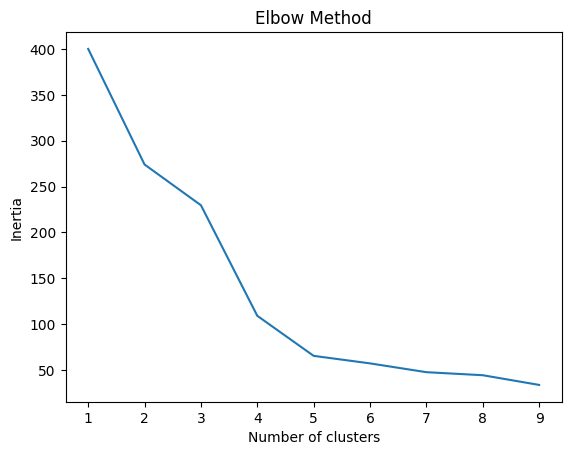

In [0]:
plt.plot(nombre_clusters, inertie3)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

In [0]:
# Implementation of our K-means
# As before, we select five clusters

kmeans3 = KMeans(n_clusters=5, random_state=42)
kmeans3.fit(X3_scaled)

KMeans(n_clusters=5, random_state=42)

In [0]:
data_clusters3 = data_prep.copy()
data_clusters3['Clusters'] = kmeans3.fit_predict(X3_scaled) 
data_clusters3.head()

,Gender,Age,Annual Income,Spending Score,Clusters
0,Male,19,15,39,2
1,Male,21,15,81,2
2,Female,20,16,6,2
3,Female,23,16,77,2
4,Female,31,17,40,2


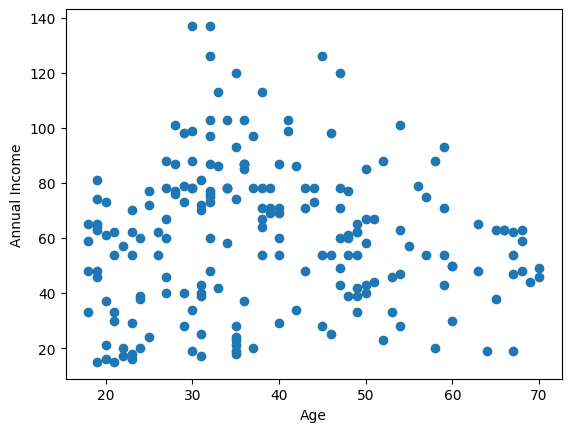

In [0]:
# Before Clustering 

plt.scatter(data_prep['Age'],data_prep['Annual Income'])
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.show()

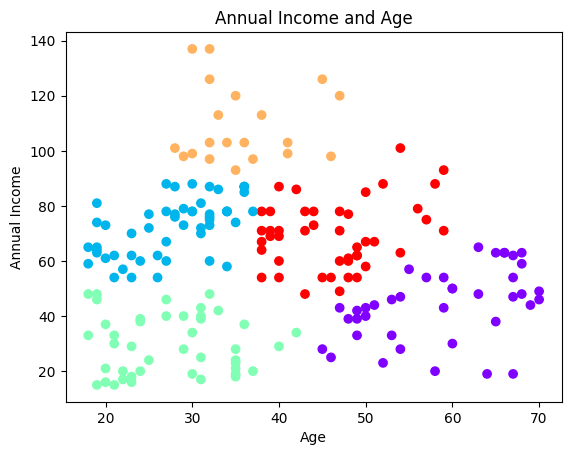

In [0]:
# After Clustering

plt.scatter(data_prep['Age'],data_prep['Annual Income'], c=data_clusters3['Clusters'], cmap='rainbow')
plt.title('Annual Income and Age')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.show()